In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("Data/big_mart_sales.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
median_sales = df["Item_Outlet_Sales"].median()

df["Sales_Class"] = (
    df["Item_Outlet_Sales"] >= median_sales
).astype(int)

print("Median Sales:", median_sales)

print(
    df["Sales_Class"].value_counts()
)

Median Sales: 1794.331
Sales_Class
1    4266
0    4257
Name: count, dtype: int64


In [4]:
X_class = df.drop(
    columns=[
        "Item_Outlet_Sales",
        "Sales_Class"
    ]
)

y_class = df["Sales_Class"]

In [5]:
numeric_columns = X_class.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X_class.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

Categorical columns:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [6]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor_class = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_columns
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_columns
    )
])

In [7]:
X_class_processed = preprocessor_class.fit_transform(
    X_class
)

print(
    "Processed Shape:",
    X_class_processed.shape
)

Processed Shape: (8523, 1604)


In [8]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class_processed,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print(
    "Training:",
    X_train_class.shape
)

print(
    "Testing:",
    X_test_class.shape
)

Training: (6818, 1604)
Testing: (1705, 1604)


In [9]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(
    X_train_class,
    y_train_class
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [10]:
y_pred_class = rf_classifier.predict(
    X_test_class
)

In [11]:
accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

print(
    f"Random Forest Classifier Accuracy: "
    f"{accuracy * 100:.2f}%"
)

Random Forest Classifier Accuracy: 82.05%


In [12]:
print(
    classification_report(
        y_test_class,
        y_pred_class,
        target_names=[
            "Low Sales",
            "High Sales"
        ]
    )
)

              precision    recall  f1-score   support

   Low Sales       0.85      0.77      0.81       852
  High Sales       0.79      0.87      0.83       853

    accuracy                           0.82      1705
   macro avg       0.82      0.82      0.82      1705
weighted avg       0.82      0.82      0.82      1705



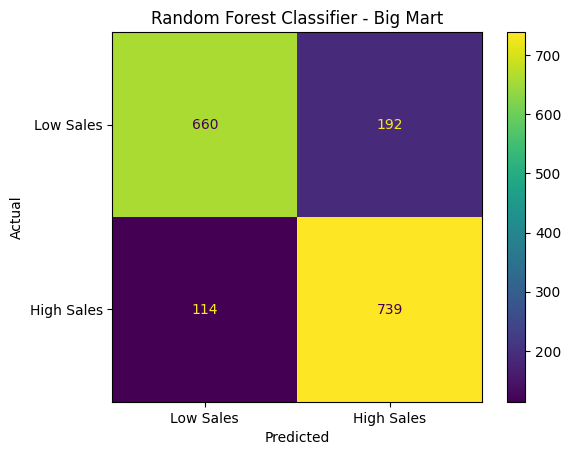

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    y_pred_class,
    display_labels=[
        "Low Sales",
        "High Sales"
    ]
)

plt.title(
    "Random Forest Classifier - Big Mart"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
feature_names = (
    preprocessor_class
    .get_feature_names_out()
)

importance = (
    rf_classifier.feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance.head(15)
)

,Feature,Importance
2,numeric__Item_MRP,0.271289
1,numeric__Item_Visibility,0.061927
0,numeric__Item_Weight,0.056847
1600,categorical__Outlet_Type_Grocery Store,0.037589
3,numeric__Outlet_Establishment_Year,0.027464
1584,categorical__Outlet_Identifier_OUT010,0.022996
1588,categorical__Outlet_Identifier_OUT019,0.018441
1589,categorical__Outlet_Identifier_OUT027,0.013327
1601,categorical__Outlet_Type_Supermarket Type1,0.011838
1603,categorical__Outlet_Type_Supermarket Type3,0.011405


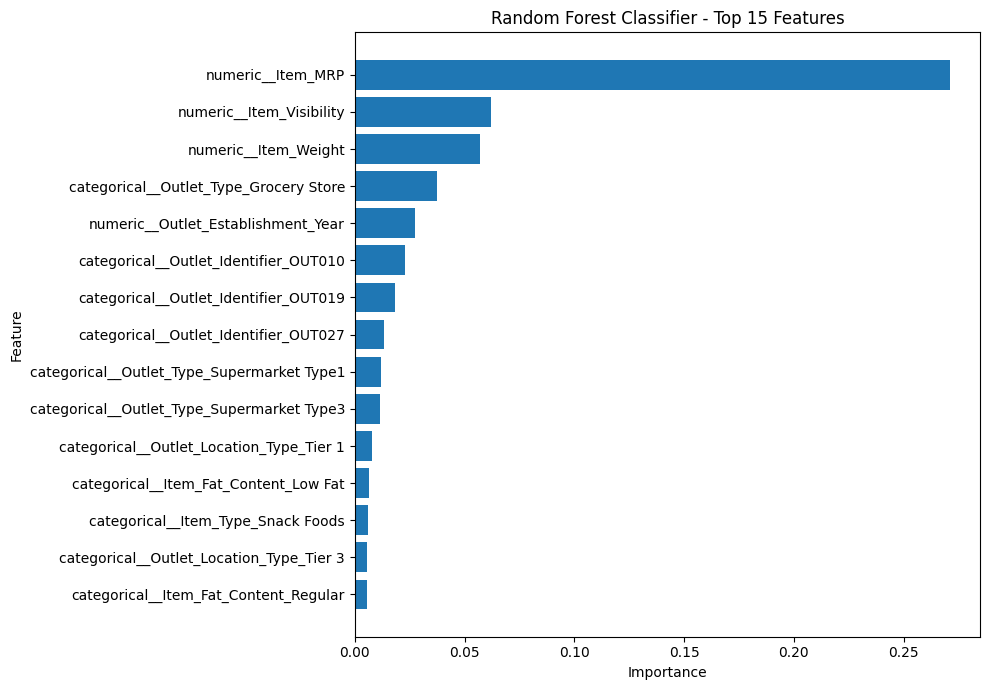

In [15]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Random Forest Classifier - Top 15 Features"
)

plt.tight_layout()

plt.show()

In [16]:
X_reg = df.drop(
    columns=[
        "Item_Outlet_Sales",
        "Sales_Class"
    ]
)

y_reg = df["Item_Outlet_Sales"]

In [17]:
numeric_columns_reg = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns_reg = X_reg.select_dtypes(
    include=["object"]
).columns

print("Numerical:")
print(list(numeric_columns_reg))

print("\nCategorical:")
print(list(categorical_columns_reg))

Numerical:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

Categorical:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [18]:
numeric_pipeline_reg = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline_reg = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor_reg = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline_reg,
        numeric_columns_reg
    ),
    (
        "categorical",
        categorical_pipeline_reg,
        categorical_columns_reg
    )
])

In [19]:
X_reg_processed = preprocessor_reg.fit_transform(
    X_reg
)

print(
    "Processed Shape:",
    X_reg_processed.shape
)

Processed Shape: (8523, 1604)


In [20]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_processed,
    y_reg,
    test_size=0.20,
    random_state=42
)

print(
    "Training:",
    X_train_reg.shape
)

print(
    "Testing:",
    X_test_reg.shape
)

Training: (6818, 1604)
Testing: (1705, 1604)


In [21]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(
    X_train_reg,
    y_train_reg
)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [22]:
y_pred_reg = rf_regressor.predict(
    X_test_reg
)

In [23]:
comparison = pd.DataFrame({
    "Actual Sales": y_test_reg.values,
    "Predicted Sales": y_pred_reg
})

display(
    comparison.head(20)
)

,Actual Sales,Predicted Sales
0,1743.0644,745.209966
1,356.8688,930.801716
2,377.5086,942.273450
3,5778.4782,4862.031132
4,2356.9320,2066.530014
5,865.5400,455.886576
6,4613.9940,5378.771828
7,2410.8618,1402.820626
8,1948.1308,1281.964610
9,1937.4780,2848.199188


In [24]:
mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

print(
    f"Mean Absolute Error: {mae:.2f}"
)

Mean Absolute Error: 757.45


In [25]:
mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

print(
    f"Mean Squared Error: {mse:.2f}"
)

Mean Squared Error: 1188734.65


In [26]:
rmse = np.sqrt(mse)

print(
    f"Root Mean Squared Error: {rmse:.2f}"
)

Root Mean Squared Error: 1090.29


In [27]:
r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print(
    f"R² Score: {r2:.4f}"
)

print(
    f"R² Score (%): {r2 * 100:.2f}%"
)

R² Score: 0.5626
R² Score (%): 56.26%


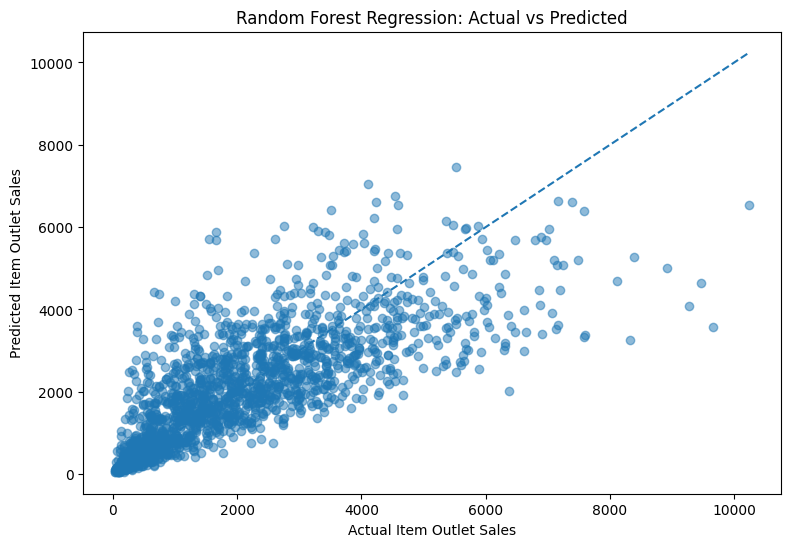

In [28]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

# Perfect prediction line
min_value = min(
    y_test_reg.min(),
    y_pred_reg.min()
)

max_value = max(
    y_test_reg.max(),
    y_pred_reg.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Item Outlet Sales"
)

plt.ylabel(
    "Predicted Item Outlet Sales"
)

plt.title(
    "Random Forest Regression: Actual vs Predicted"
)

plt.show()

In [29]:
feature_names_reg = (
    preprocessor_reg
    .get_feature_names_out()
)

importance_reg = (
    rf_regressor.feature_importances_
)

feature_importance_reg = pd.DataFrame({
    "Feature": feature_names_reg,
    "Importance": importance_reg
})

feature_importance_reg = (
    feature_importance_reg
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance_reg.head(15)
)

,Feature,Importance
2,numeric__Item_MRP,0.398930
1600,categorical__Outlet_Type_Grocery Store,0.193082
1,numeric__Item_Visibility,0.057469
1603,categorical__Outlet_Type_Supermarket Type3,0.032587
1589,categorical__Outlet_Identifier_OUT027,0.029925
0,numeric__Item_Weight,0.029686
3,numeric__Outlet_Establishment_Year,0.023471
1574,categorical__Item_Type_Fruits and Vegetables,0.003888
1591,categorical__Outlet_Identifier_OUT045,0.003746
1581,categorical__Item_Type_Snack Foods,0.003736


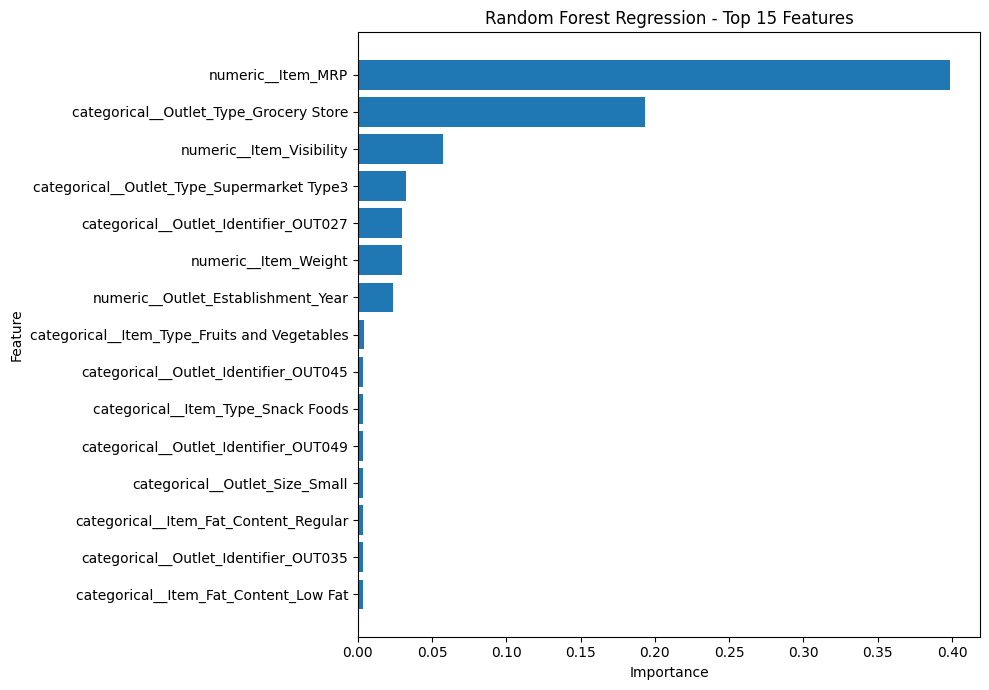

In [30]:
top_features_reg = (
    feature_importance_reg.head(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_reg["Feature"][::-1],
    top_features_reg["Importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Random Forest Regression - Top 15 Features"
)

plt.tight_layout()

plt.show()

In [31]:
residuals = (
    y_test_reg.values - y_pred_reg
)

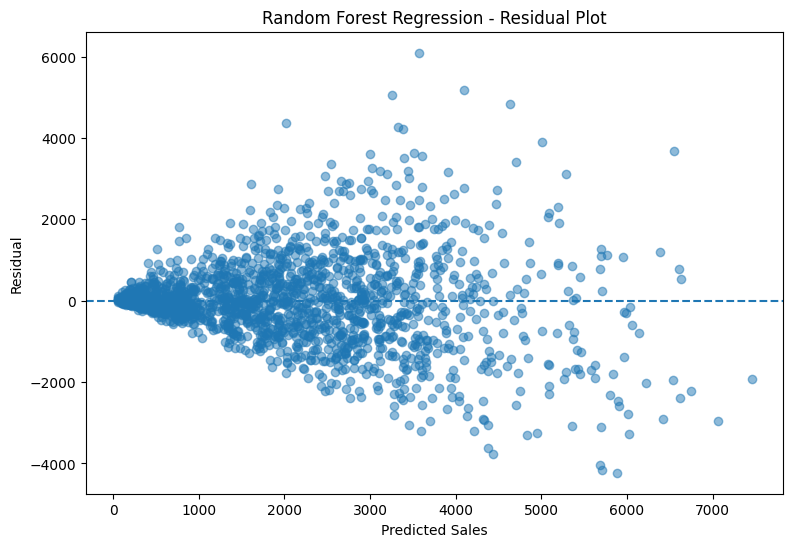

In [32]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Sales"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Random Forest Regression - Residual Plot"
)

plt.show()

In [33]:
classification_results = pd.DataFrame({
    "Model": [
        "Random Forest Classifier"
    ],
    "Accuracy": [
        accuracy * 100
    ]
})

display(
    classification_results
)

,Model,Accuracy
0,Random Forest Classifier,82.052786


In [34]:
regression_results = pd.DataFrame({
    "Model": [
        "Random Forest Regressor"
    ],
    "MAE": [
        mae
    ],
    "MSE": [
        mse
    ],
    "RMSE": [
        rmse
    ],
    "R2 Score": [
        r2
    ]
})

display(
    regression_results
)

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,757.448573,1.188735e+06,1090.291084,0.562639
